<a href="https://colab.research.google.com/github/Pranavgit2007/ML-Assignment-1-Polynomial-Regression/blob/main/ml_ass1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load the Steam Turbine training data
train_var1 = pd.read_csv('BT2024168_train_var1.csv')
X = train_var1[['x1', 'x2', 'x3', 'x4', 'x5', 'x6']]
y = train_var1['y']

# 2. Split into train and validation sets (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Test polynomial degrees from 1 to 6
max_degree = 6

print("--- Testing Polynomial Degrees for Problem 1 (var1) ---")
for degree in range(1, max_degree + 1):
    # Create polynomial features
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)

    # Scale the features (crucial for high degree polynomials to prevent massive numbers)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_poly)
    X_val_scaled = scaler.transform(X_val_poly)

    # Train the linear regression model
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

    # Predict and evaluate
    y_val_pred = model.predict(X_val_scaled)

    mse_val = mean_squared_error(y_val, y_val_pred)
    r2_val = r2_score(y_val, y_val_pred)

    print(f"Degree {degree:2d} | Validation MSE: {mse_val:15.2f} | Validation R2 Score: {r2_val:.4f}")

--- Testing Polynomial Degrees for Problem 1 (var1) ---
Degree  1 | Validation MSE:            8.79 | Validation R2 Score: 0.1302
Degree  2 | Validation MSE:            3.68 | Validation R2 Score: 0.6359
Degree  3 | Validation MSE:            1.14 | Validation R2 Score: 0.8874
Degree  4 | Validation MSE:            0.93 | Validation R2 Score: 0.9075
Degree  5 | Validation MSE:            2.30 | Validation R2 Score: 0.7719
Degree  6 | Validation MSE:           73.88 | Validation R2 Score: -6.3109


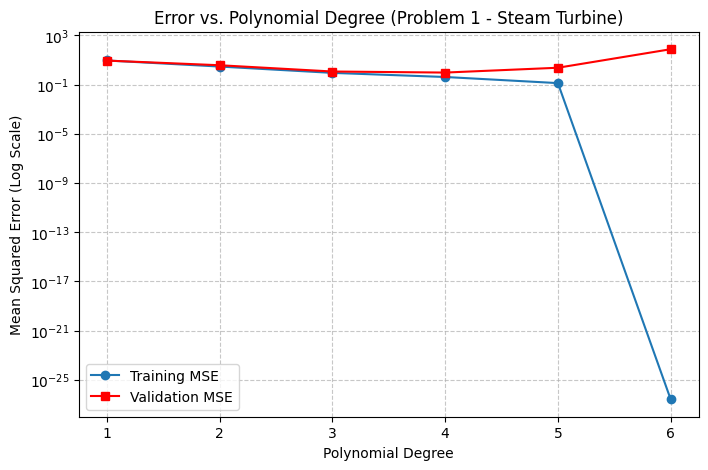

In [3]:
import matplotlib.pyplot as plt

train_mses = []
val_mses = []
degrees = range(1, 7)

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_poly)
    X_val_scaled = scaler.transform(X_val_poly)

    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

    train_mses.append(mean_squared_error(y_train, model.predict(X_train_scaled)))
    val_mses.append(mean_squared_error(y_val, model.predict(X_val_scaled)))

plt.figure(figsize=(8, 5))
plt.plot(degrees, train_mses, label='Training MSE', marker='o')
plt.plot(degrees, val_mses, label='Validation MSE', marker='s', color='red')
plt.title('Error vs. Polynomial Degree (Problem 1 - Steam Turbine)')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error (Log Scale)')
plt.yscale('log') # Log scale because Degree 6 error is huge
plt.xticks(degrees)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [4]:
# --- Final Predictions for Problem 1 (var1) ---

# 1. Load the test dataset
test_var1 = pd.read_csv('BT2024168_test_var1.csv')
X_test = test_var1[['x1', 'x2', 'x3', 'x4', 'x5', 'x6']]

# 2. Re-load full training data to train on 100% of the data this time
X_train_full = train_var1[['x1', 'x2', 'x3', 'x4', 'x5', 'x6']]
y_train_full = train_var1['y']

# 3. Apply Degree 4 Polynomial Features and Scale
poly_final = PolynomialFeatures(degree=4)
X_train_full_poly = poly_final.fit_transform(X_train_full)
X_test_poly = poly_final.transform(X_test)

scaler_final = StandardScaler()
X_train_full_scaled = scaler_final.fit_transform(X_train_full_poly)
X_test_scaled = scaler_final.transform(X_test_poly)

# 4. Train the final model
final_model = LinearRegression()
final_model.fit(X_train_full_scaled, y_train_full)

# 5. Predict on the test data
y_test_pred = final_model.predict(X_test_scaled)

# 6. Save to CSV matching the required format
submission_df1 = pd.DataFrame({'y': y_test_pred})
submission_df1.to_csv('BT2024168_pred_var1.csv', index=False)
print("Saved BT2024168_pred_var1.csv successfully!")

Saved BT2024168_pred_var1.csv successfully!


In [5]:
# --- Testing Polynomial Degrees for Problem 2 (var2) ---

# 1. Load the Thermal Reservoir training data
train_var2 = pd.read_csv('BT2024168_train_var2.csv')
X2 = train_var2[['x1', 'x2', 'x3']]
y2 = train_var2['y']

# 2. Split into train and validation sets
X2_train, X2_val, y2_train, y2_val = train_test_split(X2, y2, test_size=0.2, random_state=42)

# 3. Test polynomial degrees from 1 to 12
max_degree_2 = 12

print("--- Problem 2 (var2) Validation Results ---")
for degree in range(1, max_degree_2 + 1):
    poly2 = PolynomialFeatures(degree=degree)
    X2_train_poly = poly2.fit_transform(X2_train)
    X2_val_poly = poly2.transform(X2_val)

    scaler2 = StandardScaler()
    X2_train_scaled = scaler2.fit_transform(X2_train_poly)
    X2_val_scaled = scaler2.transform(X2_val_poly)

    model2 = LinearRegression()
    model2.fit(X2_train_scaled, y2_train)

    mse_val2 = mean_squared_error(y2_val, model2.predict(X2_val_scaled))
    r2_val2 = r2_score(y2_val, model2.predict(X2_val_scaled))

    print(f"Degree {degree:2d} | Validation MSE: {mse_val2:15.2f} | Validation R2: {r2_val2:.4f}")

--- Problem 2 (var2) Validation Results ---
Degree  1 | Validation MSE:           28.16 | Validation R2: 0.1781
Degree  2 | Validation MSE:           17.17 | Validation R2: 0.4988
Degree  3 | Validation MSE:            9.01 | Validation R2: 0.7369
Degree  4 | Validation MSE:            2.97 | Validation R2: 0.9132
Degree  5 | Validation MSE:            1.12 | Validation R2: 0.9673
Degree  6 | Validation MSE:            0.49 | Validation R2: 0.9856
Degree  7 | Validation MSE:            0.33 | Validation R2: 0.9905
Degree  8 | Validation MSE:            0.29 | Validation R2: 0.9916
Degree  9 | Validation MSE:            0.31 | Validation R2: 0.9910
Degree 10 | Validation MSE:            0.33 | Validation R2: 0.9904
Degree 11 | Validation MSE:            0.50 | Validation R2: 0.9855
Degree 12 | Validation MSE:            0.53 | Validation R2: 0.9845


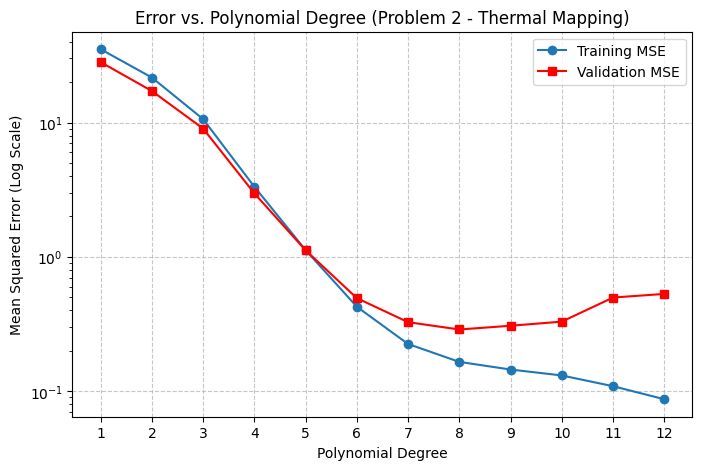

In [6]:
import matplotlib.pyplot as plt

train_mses2 = []
val_mses2 = []
degrees2 = range(1, 13)

for degree in degrees2:
    poly2 = PolynomialFeatures(degree=degree)
    X2_train_poly = poly2.fit_transform(X2_train)
    X2_val_poly = poly2.transform(X2_val)

    scaler2 = StandardScaler()
    X2_train_scaled = scaler2.fit_transform(X2_train_poly)
    X2_val_scaled = scaler2.transform(X2_val_poly)

    model2 = LinearRegression()
    model2.fit(X2_train_scaled, y2_train)

    train_mses2.append(mean_squared_error(y2_train, model2.predict(X2_train_scaled)))
    val_mses2.append(mean_squared_error(y2_val, model2.predict(X2_val_scaled)))

plt.figure(figsize=(8, 5))
plt.plot(degrees2, train_mses2, label='Training MSE', marker='o')
plt.plot(degrees2, val_mses2, label='Validation MSE', marker='s', color='red')
plt.title('Error vs. Polynomial Degree (Problem 2 - Thermal Mapping)')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error (Log Scale)')
plt.yscale('log')
plt.xticks(degrees2)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [7]:
# --- Final Predictions for Problem 2 (var2) ---

# 1. Load the test dataset
test_var2 = pd.read_csv('BT2024168_test_var2.csv')
X2_test = test_var2[['x1', 'x2', 'x3']]

# 2. Re-load full training data
X2_train_full = train_var2[['x1', 'x2', 'x3']]
y2_train_full = train_var2['y']

# 3. Apply optimal Degree 8 features and scale
poly2_final = PolynomialFeatures(degree=8)
X2_train_full_poly = poly2_final.fit_transform(X2_train_full)
X2_test_poly = poly2_final.transform(X2_test)

scaler2_final = StandardScaler()
X2_train_full_scaled = scaler2_final.fit_transform(X2_train_full_poly)
X2_test_scaled = scaler2_final.transform(X2_test_poly)

# 4. Train the final model
final_model2 = LinearRegression()
final_model2.fit(X2_train_full_scaled, y2_train_full)

# 5. Predict on test data
y2_test_pred = final_model2.predict(X2_test_scaled)

# 6. Save to CSV matching the required format
submission_df2 = pd.DataFrame({'y': y2_test_pred})
submission_df2.to_csv('BT2024168_pred_var2.csv', index=False)
print("Saved BT2024168_pred_var2.csv successfully!")

Saved BT2024168_pred_var2.csv successfully!
